<a href="https://colab.research.google.com/github/12eyzha/Trial/blob/main/2318071_DataCleansing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#2. Baca Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/Post_Covid1k.csv"
df = pd.read_csv(file_path)


#3. Mengecek missing value


In [ ]:
print("Jumlah Missing Value per Kolom:")
print(df.isnull().sum())

Jumlah Missing Value per Kolom:
Indicator                 0
Group                     0
State                     0
Subgroup                  0
Phase                     0
Time Period               0
Time Period Label         0
Time Period Start Date    0
Time Period End Date      0
Value                     0
LowCI                     0
HighCI                    0
Confidence Interval       5
Quartile range            0
Quartile number           0
dtype: int64


#4. Perbaikan Missing Value

Misal: isi nilai kosong numerik dengan mean, dan teks dengan modus

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipython-input-2986283675.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipython-input-2986283675.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

#5 Cek Ulang Missing Value

In [ ]:
print("\nSetelah perbaikan, Missing Value per Kolom:")
print(df.isnull().sum())

#6. Cek Dan Hapus Duplikasi

In [ ]:
print(f"\nJumlah data duplikat: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Jumlah data setelah hapus duplikat: {len(df)}")


Jumlah data duplikat: 0
Jumlah data setelah hapus duplikat: 1000


#7 Cek Outlier (contoh kolom numerik)

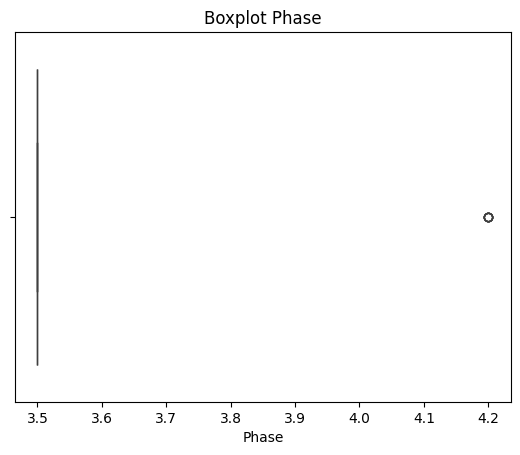

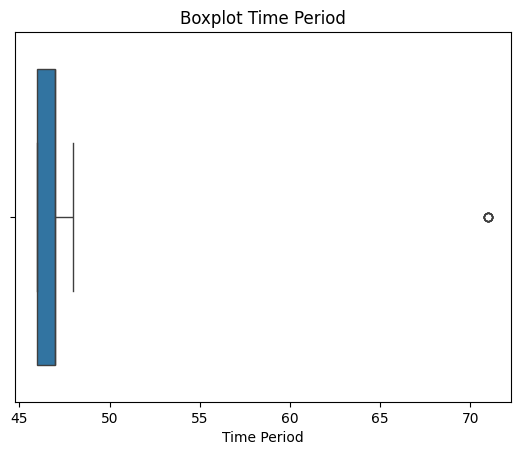

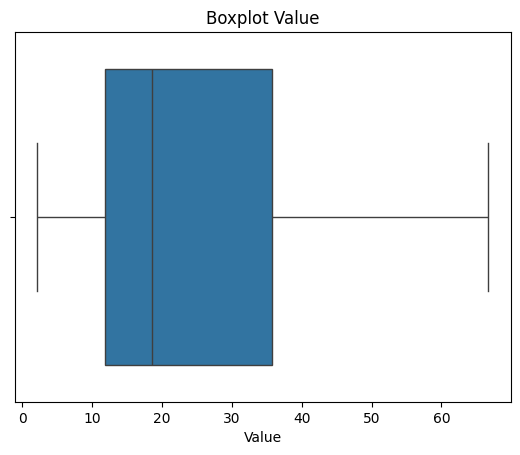

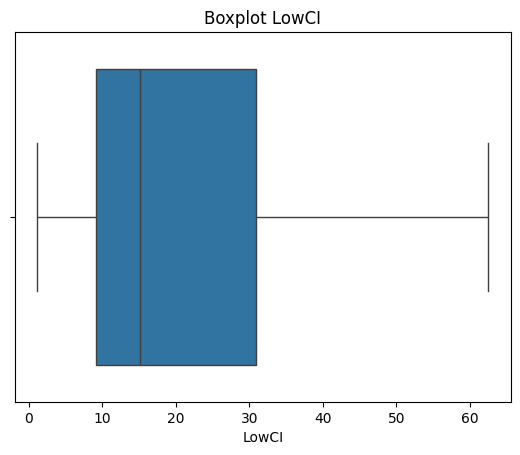

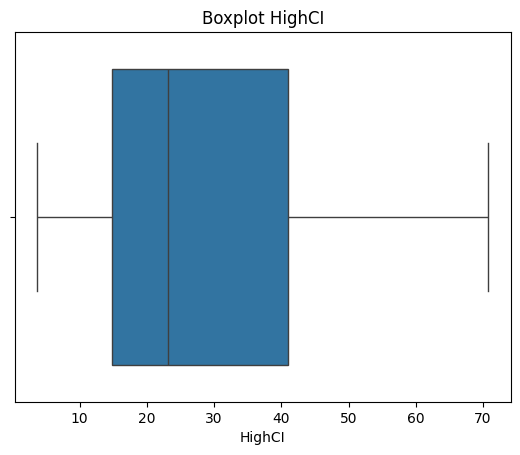

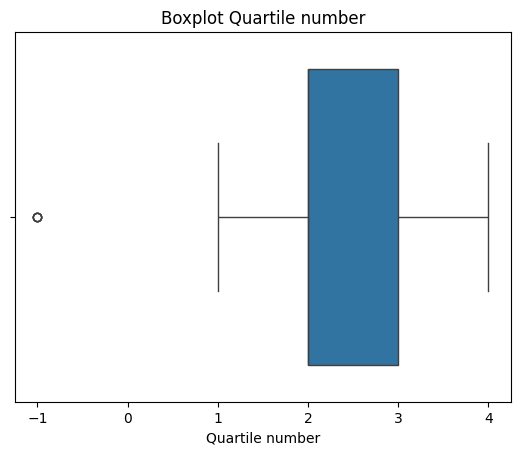

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot {col}")
    plt.show()

Menghapus outlier dengan metode IQR

In [ ]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    df = df[(df[col] >= batas_bawah) & (df[col] <= batas_atas)]


#8. Standarisasi Format Data

Contoh ubah semua nama kolom jadi lowercase tanpa spasi

In [ ]:
df.drop_duplicates(inplace=True)

Contoh standarisasi teks: ubah huruf kapital jadi kecil

In [ ]:
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip().str.lower()

#9. Cek Nilai Tidak Valid

Contoh pastikan umur tidak negatif atau terlalu besar

In [ ]:
if 'age' in df.columns:
    df = df[(df['age'] > 0) & (df['age'] < 120)]

#10.Cek Kolom Tidak Relevan

Misalnya kolom ID atau catatan kosong tidak dipakai

In [ ]:
drop_cols = ['id', 'notes', 'unnamed:_0']
drop_cols = [col for col in drop_cols if col in df.columns]
df.drop(columns=drop_cols, inplace=True)

#11. Dataset Setelah Cleansing

In [ ]:
print("\nDataset setelah proses cleansing:")
print(df.info())
print(df.head())


Dataset setelah proses cleansing:
<class 'pandas.core.frame.DataFrame'>
Index: 990 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Indicator               990 non-null    object        
 1   Group                   990 non-null    object        
 2   State                   990 non-null    object        
 3   Subgroup                990 non-null    object        
 4   Phase                   990 non-null    float64       
 5   Time Period             990 non-null    int64         
 6   Time Period Label       990 non-null    object        
 7   Time Period Start Date  990 non-null    datetime64[ns]
 8   Time Period End Date    990 non-null    datetime64[ns]
 9   Value                   990 non-null    float64       
 10  LowCI                   990 non-null    float64       
 11  HighCI                  990 non-null    float64       
 12  Confidence Interval 

#12. Kesimpulan

In [ ]:
print("\n--- KESIMPULAN ---")
print(f"Total data akhir setelah cleansing: {df.shape[0]} baris dan {df.shape[1]} kolom.")
print("Dataset telah dibersihkan dari missing value, duplikasi, outlier, dan kolom tidak relevan.")
print("Format data telah distandarkan dan siap digunakan untuk analisis lebih lanjut.")


--- KESIMPULAN ---
Total data akhir setelah cleansing: 990 baris dan 15 kolom.
Dataset telah dibersihkan dari missing value, duplikasi, outlier, dan kolom tidak relevan.
Format data telah distandarkan dan siap digunakan untuk analisis lebih lanjut.
